# Plot Generation Suitability

This notebook creates plots comparing the available generation in 2050 for solar and wind compared the target generation needed to achieve High Renewables scenario generation.

## Imports

In [167]:
import pandas as pd
import geopandas as gpd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import os
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch
import math

## Data Paths

In [168]:
# data dir
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# output data
output_data_dir = os.path.join(data_dir, 'output_data')

# input data dir
input_data_dir = os.path.join(data_dir, 'input_data')

# output figure dir
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

# path to suitability case df
suitability_data_path = os.path.join(output_data_dir, f'capacity_factor_case_2050.csv')

# western interconnection shapefile
wecc_shp_path = os.path.join(input_data_dir, 'wecc_boundary_shp', 'wecc_boundary.shp')

# transmission shapefile
transmission_path = os.path.join(input_data_dir, 'wecc_transmission_shp', 'wecc_transmission_250kv.shp')
                                 

## Functions

## Collect Data

In [169]:
state_abbr = {'WA': 'washington',
              'NM':'new_mexico',
              'CA': 'california',
              'OR': 'oregon',
              'ID':'idaho',
              'NV': 'nevada',
              'MT': 'montana',
              'AZ':'arizona',
              'CO': 'colorado',
              'UT':'utah',
              'WY':'wyoming'}

# https://jgcri.github.io/gcam-doc/v6.0/gcam-usa.html
gcam_trading_regions = {
             'arizona': 'SW Grid',
             'california': 'CA Grid',
             'colorado': 'SW Grid',
             'idaho': 'NW Grid',
             'montana': 'NW Grid',
             'new_mexico': 'SW Grid',
             'nevada': 'NW Grid',
             'oregon': 'NW Grid',
             'utah': 'NW Grid',
             'washington': 'NW Grid',
             'wyoming': 'SW Grid'}

# Define the sorted order of scenarios in the plot
sorter = {'baseline':"1", 
          'dac':"2", 
          'farmland':"3", 
          'env_1':"4", 
          'env_1_1km':"5", 
          'env_1_5km':"6", 
          'env_1_10km':"7", 
          'env_2':"8", 
          'env_2_1km':"9", 
          'env_2_5km':"10", 
          'env_2_10km':"11", 
           'env_3':"12", 
          'env_3_1km':"13", 
          'env_3_5km':"14", 
          'env_3_10km':"15", 
          'dac_farm_env1':"16", 
           'dac_farm_env2':"17", 
          'dac_farm_env3':"18", 
          'dac_farm_env1_1km':"19", 
           'dac_farm_env2_1km':"20", 
          'dac_farm_env3_1km':"21", 
          'dac_farm_env1_5km':"22", 
           'dac_farm_env2_5km':"23", 
          'dac_farm_env3_5km':"24", 
          'dac_farm_env1_10km':"25", 
           'dac_farm_env2_10km':"26",  
          'dac_farm_env3_10km':"27", 
         }

# Create the dictionary that defines the order for sorting
sorterIndex = dict(zip(sorter, range(len(sorter))))

### Prep shapefiles

In [170]:
# read western interconnection shapefile
wecc_shp = gpd.read_file(wecc_shp_path)
wecc_shp['trading_region'] = wecc_shp['STATE_ABBR'].map(state_abbr).map(gcam_trading_regions)
state_shp = wecc_shp.copy()
wecc_shp = wecc_shp.dissolve(by='trading_region', as_index=False)

# read transmission shapefile
transmission = gpd.read_file(transmission_path)

In [171]:
#read case results
base_df = pd.read_csv((os.path.join(output_data_dir, 'capacity_factor_analysis_2050.csv')))
base_df['case_number'] = base_df['case'].map(sorter)
base_df['label'] = base_df['case_number'] + '. ' + base_df['case']

### Sort and Group Data - Base capacity density

In [172]:
# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_120m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 6]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case','case_number', 'label'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 45].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number', 'label'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

## Figure 5 - GCAM-USA Trading Region Comparison with Base Capacity Density assumptions

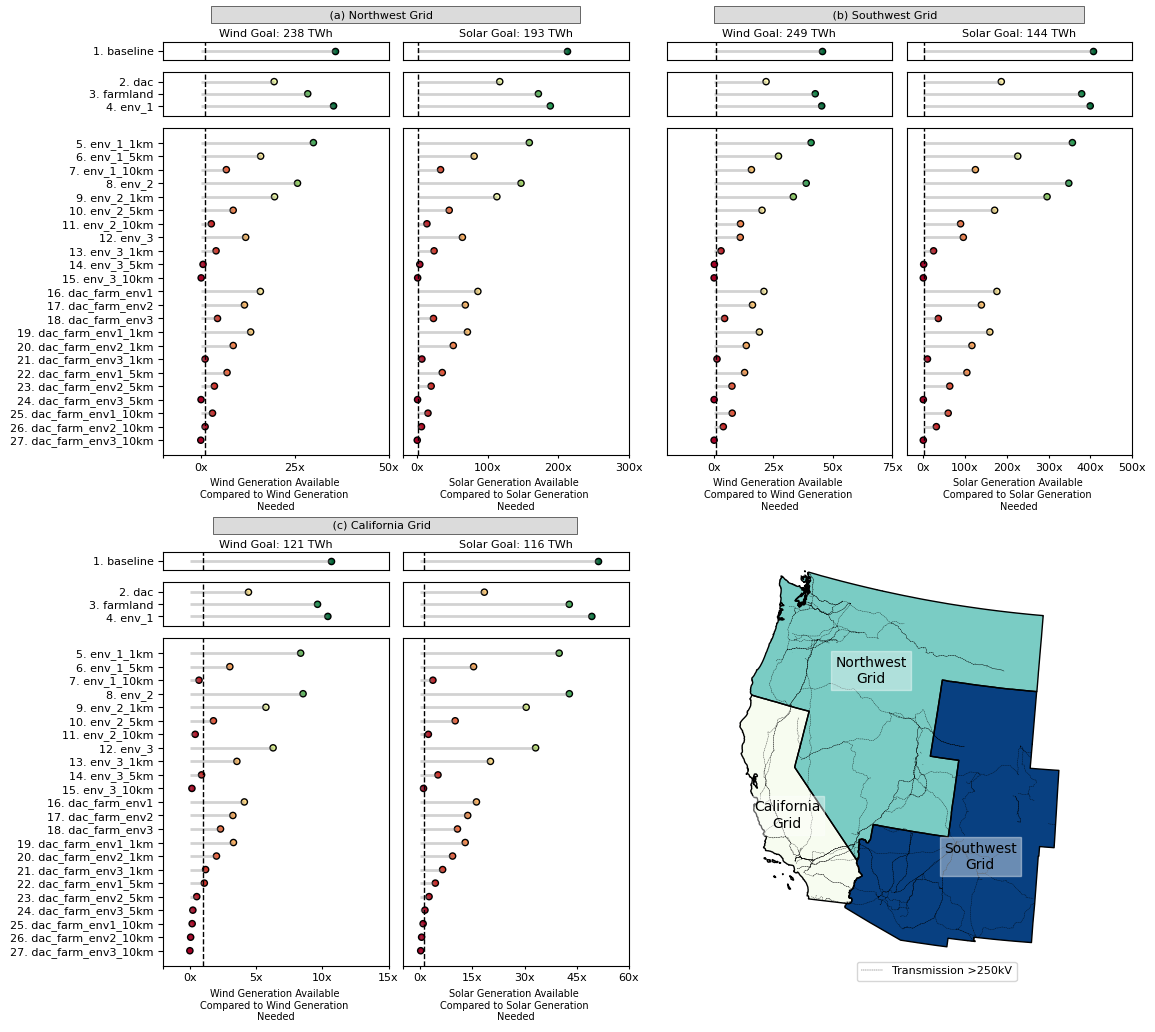

In [173]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                 (a) Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))


# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-10, right=50)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-10, right=50)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-10, right=50)
ax.set_xticks(ticks=[-10,0,25, 50], labels=['','0x','25x', '50x'])



#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=300)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=300)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=300)
ax.set_xticks(ticks=[-20,0,100, 200, 300], labels=['','0x', '100x','200x', '300x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                 (b) Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=75)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-20, right=75)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=75)
ax.set_xticks(ticks=[ 0, 25, 50, 75], labels=['0x', '25x','50x','75x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[0, 100, 200, 300, 400, 500], labels=['0x', '100x', '200x', '300x','400x', '500x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                 (c) California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-2, right=15)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-2, right=15)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-2, right=15)
ax.set_xticks(ticks=[-2, 0, 5, 10, 15], labels=['','0x','5x', '10x', '15x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0,15, 30, 45, 60], labels=['','0x','15x', '30x','45x','60x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_5_generation_suitability_sensitivity_analysis.png'), bbox_inches='tight', dpi=300)


plt.show()

# Power Density Sensitivity case

### 6 MW wind, 15 MW Solar Capacity Density Sensitivity case, 120m hub height

In [174]:

# state case
wind = base_df[base_df.technology == 'Wind_120m'].copy()
wind = wind[wind.capacity_density_mw == 6].copy()
wind['Rank'] = wind['case'].map(sorterIndex)
wind.sort_values(['Rank'], ascending = [False], inplace = True)
wind['target_generation_twh'] = wind['target_generation_mwh'] / 1000000
wind['total_generation_twh'] = wind['total_generation_mwh'] / 1000000
wind['diff'] = (wind['total_generation_twh'] / wind['target_generation_twh']) 
region_list = sorted(list(wind.region_name.unique()))
case_list = (list(wind.case.unique()))

solar = base_df[base_df.technology == 'Solar PV'].copy()
solar['Rank'] = solar['case'].map(sorterIndex)
solar = solar[solar.capacity_density_mw == 15].copy()
solar.sort_values(['Rank'], ascending = [False], inplace = True)
solar['target_generation_twh'] = solar['target_generation_mwh'] / 1000000
solar['total_generation_twh'] = solar['total_generation_mwh'] / 1000000
solar['diff'] =  (solar['total_generation_twh'] / solar['target_generation_twh'])
region_list = sorted(list(solar.region_name.unique()))
case_list = (list(solar.case.unique()))

# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_120m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 6]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 15].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [175]:
low_wind_trading_120 = wind_trading.copy()
low_wind_trading_120['type'] = 'low'
low_wind_trading_120['cap'] = 6
low_wind_trading_120['tech'] = 'Wind_120m'
low_solar_trading_120 = solar_trading.copy()
low_solar_trading_120['cap'] = 15
low_solar_trading_120['tech'] = 'Solar'

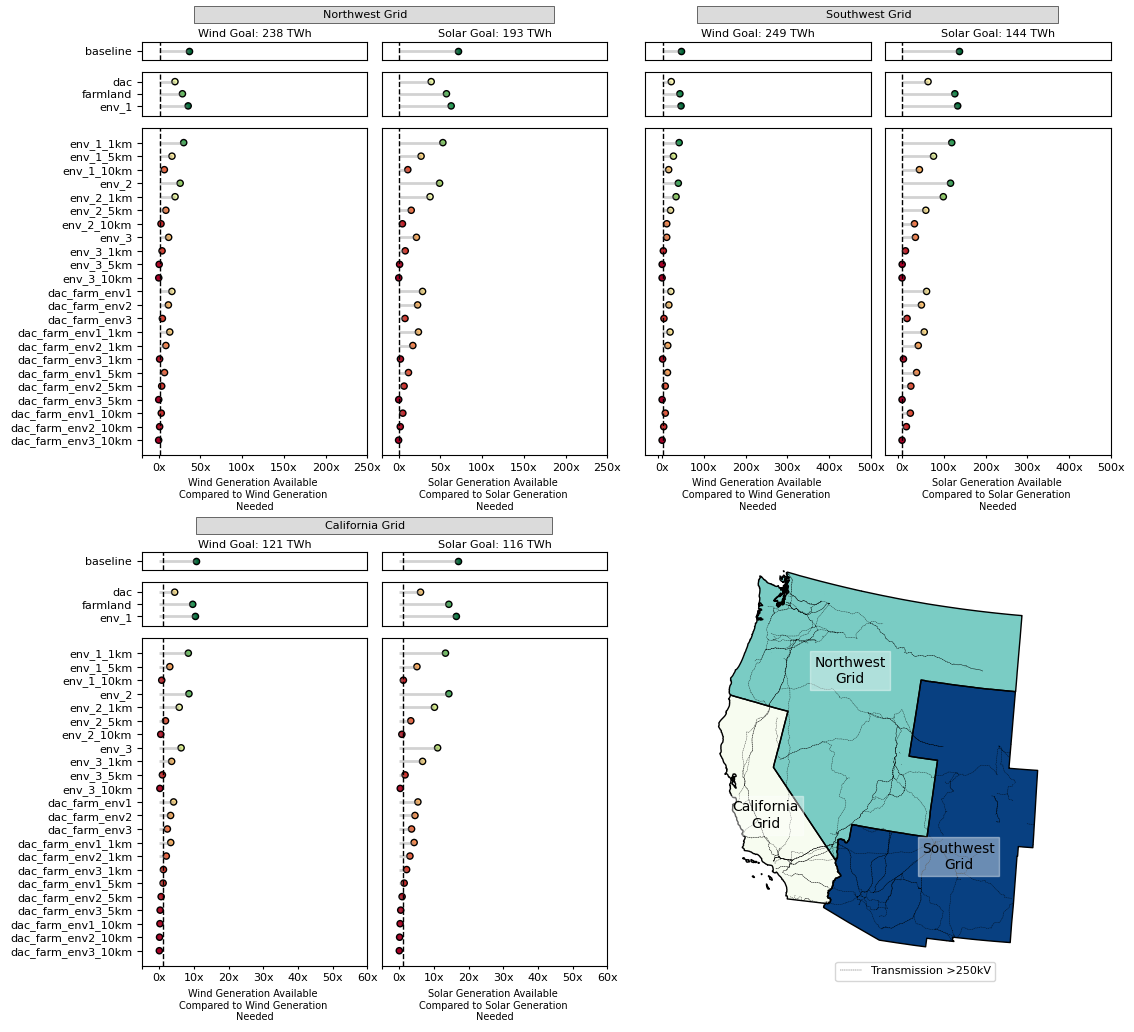

In [176]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_6wind_15solar_120m.png'), bbox_inches='tight', dpi=300)
plt.show()

## 12 MW wind, 30 MW solar capacity density case, 120m hub-height

In [177]:
# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_120m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 12]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case','case_number', 'label'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 30].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number', 'label'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [178]:
base_wind_trading = wind_trading.copy()
base_wind_trading['type'] = 'base'
base_wind_trading['cap'] = 12
base_wind_trading['tech'] = 'Wind_120m'
base_solar_trading = solar_trading.copy()
base_solar_trading['type'] = 'base'
base_solar_trading['cap'] = 30
base_solar_trading['tech'] = 'Solar'

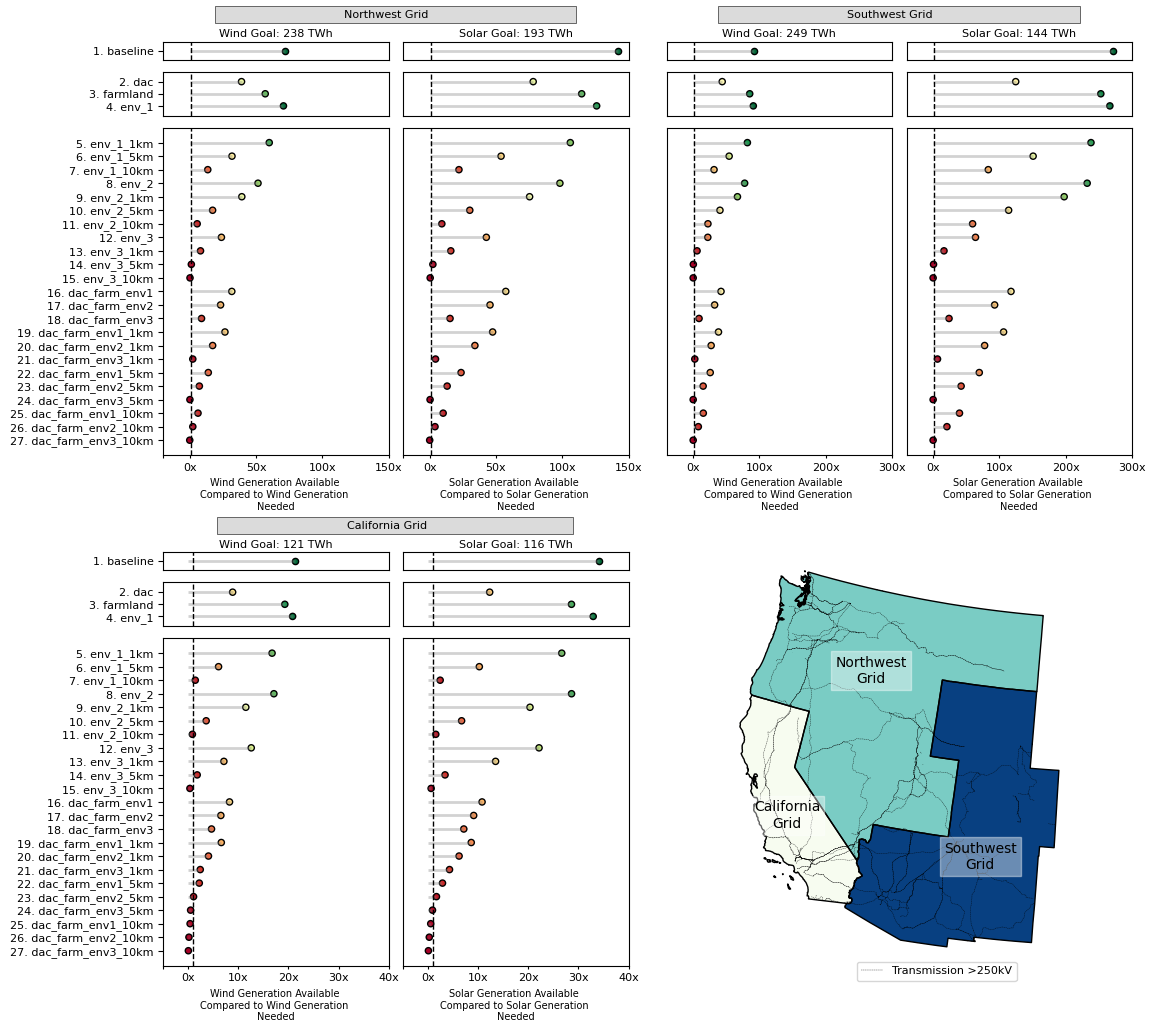

In [179]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=150)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=150)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=150)
ax.set_xticks(ticks=[-20,0,50, 100, 150], labels=['','0x','50x', '100x', '150x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=150)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=150)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=150)
ax.set_xticks(ticks=[-20,0,50, 100, 150], labels=['','0x','50x', '100x', '150x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=300)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=300)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=300)
ax.set_xticks(ticks=[ 0, 100, 200, 300], labels=['0x', '100x', '200x', '300x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=300)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=300)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=300)
ax.set_xticks(ticks=[0, 100, 200, 300], labels=['0x', '100x', '200x', '300x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=40)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=40)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=40)
ax.set_xticks(ticks=[-5, 0, 10, 20, 30, 40], labels=['','0x','10x', '20x', '30x', '40x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=40)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=40)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=40)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40], labels=['','0x', '10x','20x', '30x','40x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_12wind_30solar_120m.png'),bbox_inches='tight', dpi=300)


plt.show()

### 18 MW wind, 45 MW solar Capacity Density Sensitivity case, 120m hub height

In [180]:
# state case
wind = base_df[base_df.technology == 'Wind_120m'].copy()
wind = wind[wind.capacity_density_mw == 18].copy()
wind['Rank'] = wind['case'].map(sorterIndex)
wind.sort_values(['Rank'], ascending = [False], inplace = True)
wind['target_generation_twh'] = wind['target_generation_mwh'] / 1000000
wind['total_generation_twh'] = wind['total_generation_mwh'] / 1000000
wind['diff'] = (wind['total_generation_twh'] / wind['target_generation_twh'])
region_list = sorted(list(wind.region_name.unique()))
case_list = (list(wind.case.unique()))

solar = base_df[base_df.technology == 'Solar PV'].copy()
solar['Rank'] = solar['case'].map(sorterIndex)
solar = solar[solar.capacity_density_mw == 45].copy()
solar.sort_values(['Rank'], ascending = [False], inplace = True)
solar['target_generation_twh'] = solar['target_generation_mwh'] / 1000000
solar['total_generation_twh'] = solar['total_generation_mwh'] / 1000000
solar['diff'] =  (solar['total_generation_twh'] / solar['target_generation_twh'])
region_list = sorted(list(solar.region_name.unique()))
case_list = (list(solar.case.unique()))

# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_120m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 18]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 45].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [181]:
high_wind_trading_120 = wind_trading.copy()
high_wind_trading_120['type'] = 'high'
high_wind_trading_120['cap'] = 18
high_wind_trading_120['tech'] =  'Wind_120m'
high_solar_trading_120 = solar_trading.copy()
high_solar_trading_120['type'] = 'high'
high_solar_trading_120['cap'] =  45
high_solar_trading_120['tech'] = 'Solar'

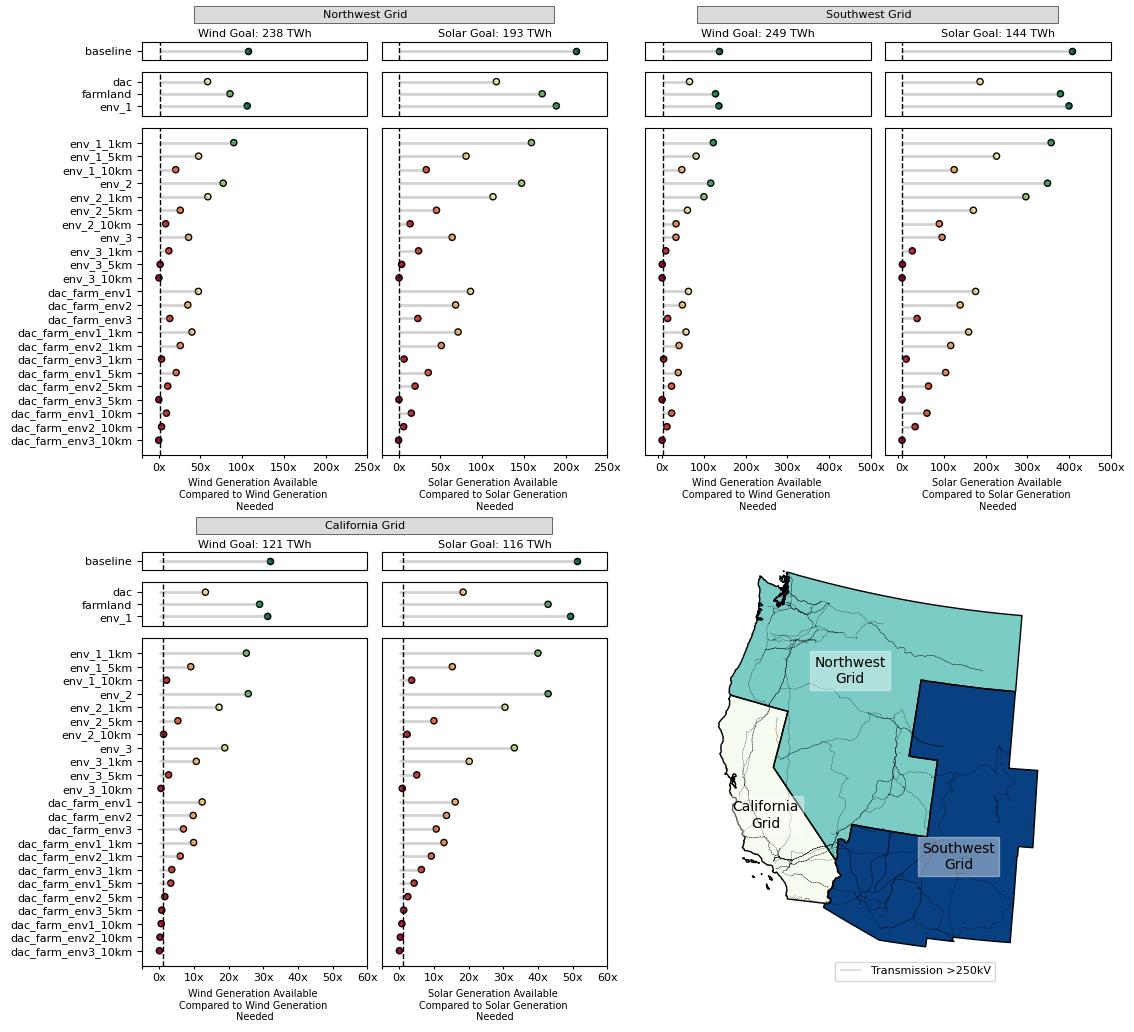

In [182]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_18wind_45solar_120m.png'), bbox_inches='tight',dpi=300)

plt.show()

## Extra High Power Density Sensitivity case, 120m hub height

In [183]:
# state case
wind = base_df[base_df.technology == 'Wind_120m'].copy()
wind = wind[wind.capacity_density_mw == 24].copy()
wind['Rank'] = wind['case'].map(sorterIndex)
wind.sort_values(['Rank'], ascending = [False], inplace = True)
wind['target_generation_twh'] = wind['target_generation_mwh'] / 1000000
wind['total_generation_twh'] = wind['total_generation_mwh'] / 1000000
wind['diff'] = (wind['total_generation_twh'] / wind['target_generation_twh'])
region_list = sorted(list(wind.region_name.unique()))
case_list = (list(wind.case.unique()))

solar = base_df[base_df.technology == 'Solar PV'].copy()
solar['Rank'] = solar['case'].map(sorterIndex)
solar = solar[solar.capacity_density_mw == 60].copy()
solar.sort_values(['Rank'], ascending = [False], inplace = True)
solar['target_generation_twh'] = solar['target_generation_mwh'] / 1000000
solar['total_generation_twh'] = solar['total_generation_mwh'] / 1000000
solar['diff'] =  (solar['total_generation_twh'] / solar['target_generation_twh'])
region_list = sorted(list(solar.region_name.unique()))
case_list = (list(solar.case.unique()))

# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_120m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 24]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 60].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [184]:
extra_high_wind_trading_120 = wind_trading.copy()
extra_high_wind_trading_120['type'] = 'extra_high'
extra_high_wind_trading_120['cap'] = 24
extra_high_wind_trading_120['tech'] =  'Wind_120m'
extra_high_solar_trading_120 = solar_trading.copy()
extra_high_solar_trading_120['cap'] = 60
extra_high_solar_trading_120['type'] = 'extra_high'
extra_high_solar_trading_120['tech'] = 'Solar'

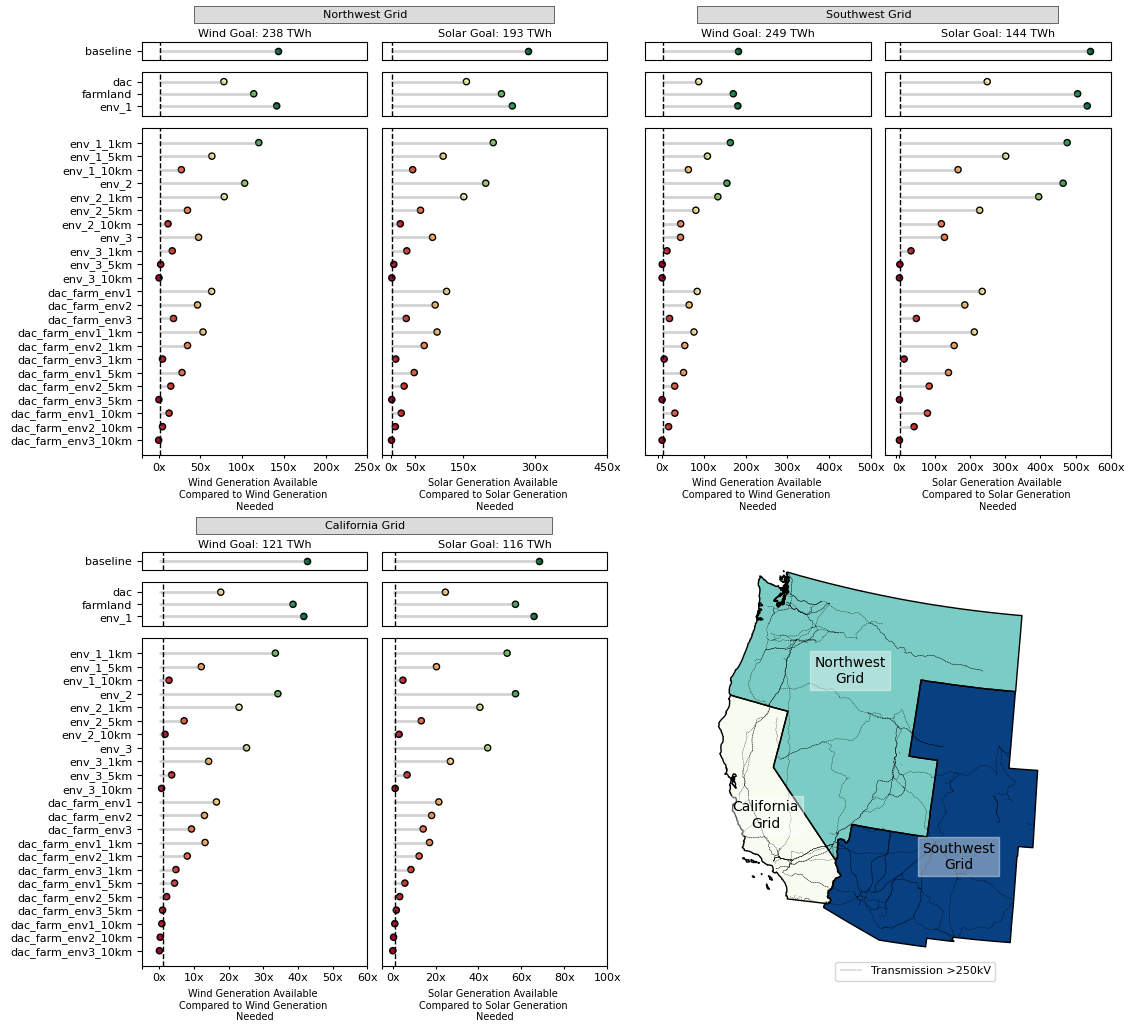

In [185]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=450)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=450)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 150, 300, 450], labels=['','0x','50x',  '150x','300x', '450x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=600)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=600)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500, 600], labels=['','0x', '100x', '200x', '300x', '400x', '500x', '600x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=100)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=100)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 20, 40, 60, 80, 100], labels=['','0x', '20x', '40x',  '60x', '80x', '100x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_24wind_60solar_120m.png'), dpi=300, bbox_inches='tight',)

plt.show()

### Lower Power Density Sensitivity case, 100m hub height

In [186]:

# state case
wind = base_df[base_df.technology == 'Wind_100m'].copy()
wind = wind[wind.capacity_density_mw == 6].copy()
wind['Rank'] = wind['case'].map(sorterIndex)
wind.sort_values(['Rank'], ascending = [False], inplace = True)
wind['target_generation_twh'] = wind['target_generation_mwh'] / 1000000
wind['total_generation_twh'] = wind['total_generation_mwh'] / 1000000
wind['diff'] = (wind['total_generation_twh'] / wind['target_generation_twh']) 
region_list = sorted(list(wind.region_name.unique()))
case_list = (list(wind.case.unique()))

solar = base_df[base_df.technology == 'Solar PV'].copy()
solar['Rank'] = solar['case'].map(sorterIndex)
solar = solar[solar.capacity_density_mw == 15].copy()
solar.sort_values(['Rank'], ascending = [False], inplace = True)
solar['target_generation_twh'] = solar['target_generation_mwh'] / 1000000
solar['total_generation_twh'] = solar['total_generation_mwh'] / 1000000
solar['diff'] =  (solar['total_generation_twh'] / solar['target_generation_twh'])
region_list = sorted(list(solar.region_name.unique()))
case_list = (list(solar.case.unique()))

# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_100m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 6]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 15].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [187]:
low_wind_trading_100 = wind_trading.copy()
low_wind_trading_100['type'] = 'low'
low_wind_trading_100['cap'] = 6
low_wind_trading_100['tech'] = 'Wind_100m'
low_solar_trading_100 = solar_trading.copy()
low_solar_trading_100['cap'] = 15
low_solar_trading_100['type'] = 'low'
low_solar_trading_100['tech'] = 'solar_100'

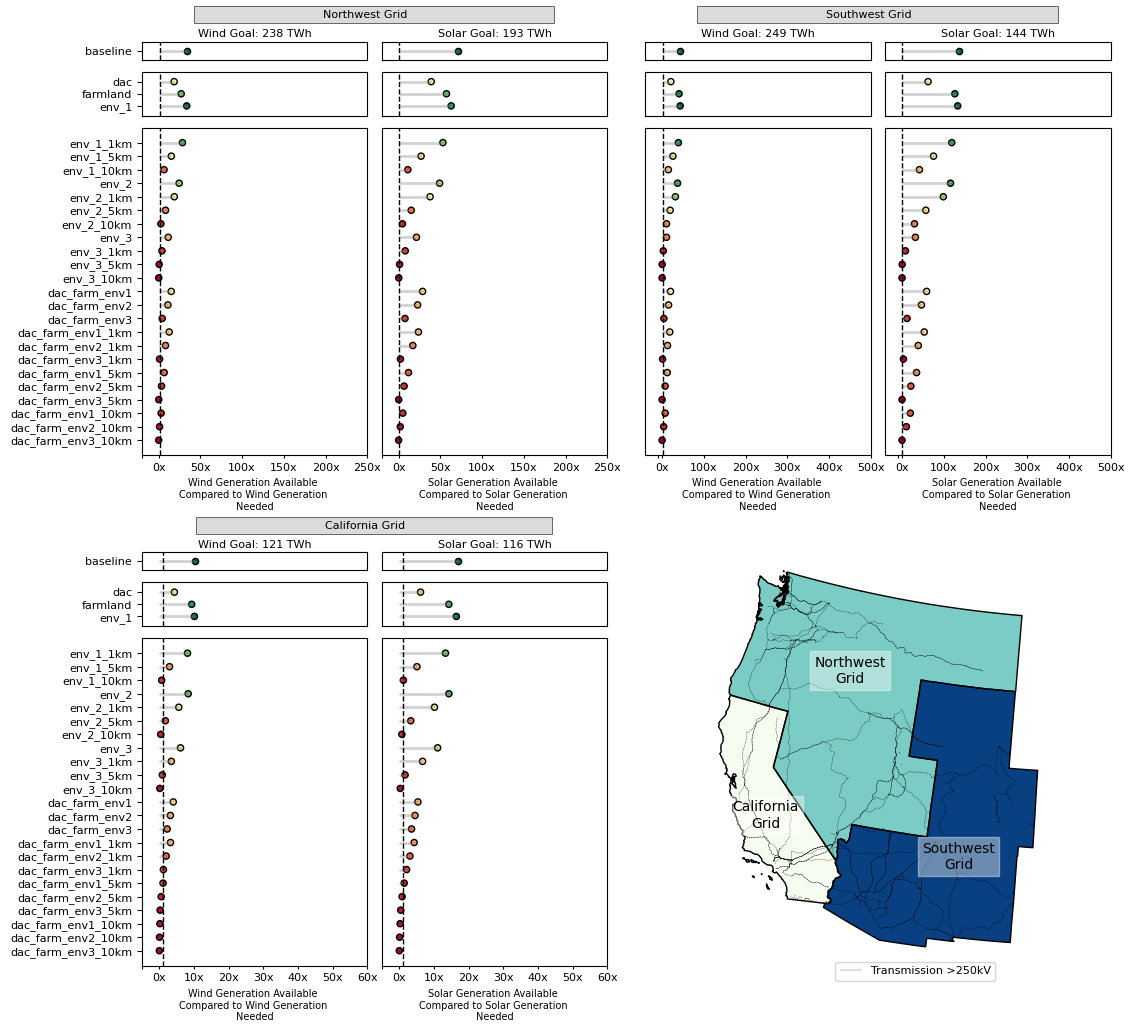

In [188]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_6wind_15solar_100m.png'), dpi=300, bbox_inches='tight',)
plt.show()

## 12 MW wind, 30 MW solar capacity density case, 100m hub-height

In [189]:
# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_100m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 12]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case','case_number', 'label'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 30].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number', 'label'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [190]:
base_wind_100_trading = wind_trading.copy()
base_wind_100_trading['type'] = 'base'
base_wind_100_trading['cap'] = 12
base_wind_100_trading['tech'] = 'Wind_100m'
base_solar_100_trading = solar_trading.copy()
base_solar_100_trading['type'] = 'base'
base_solar_100_trading['cap'] = 30
base_solar_100_trading['tech'] = 'solar_100'

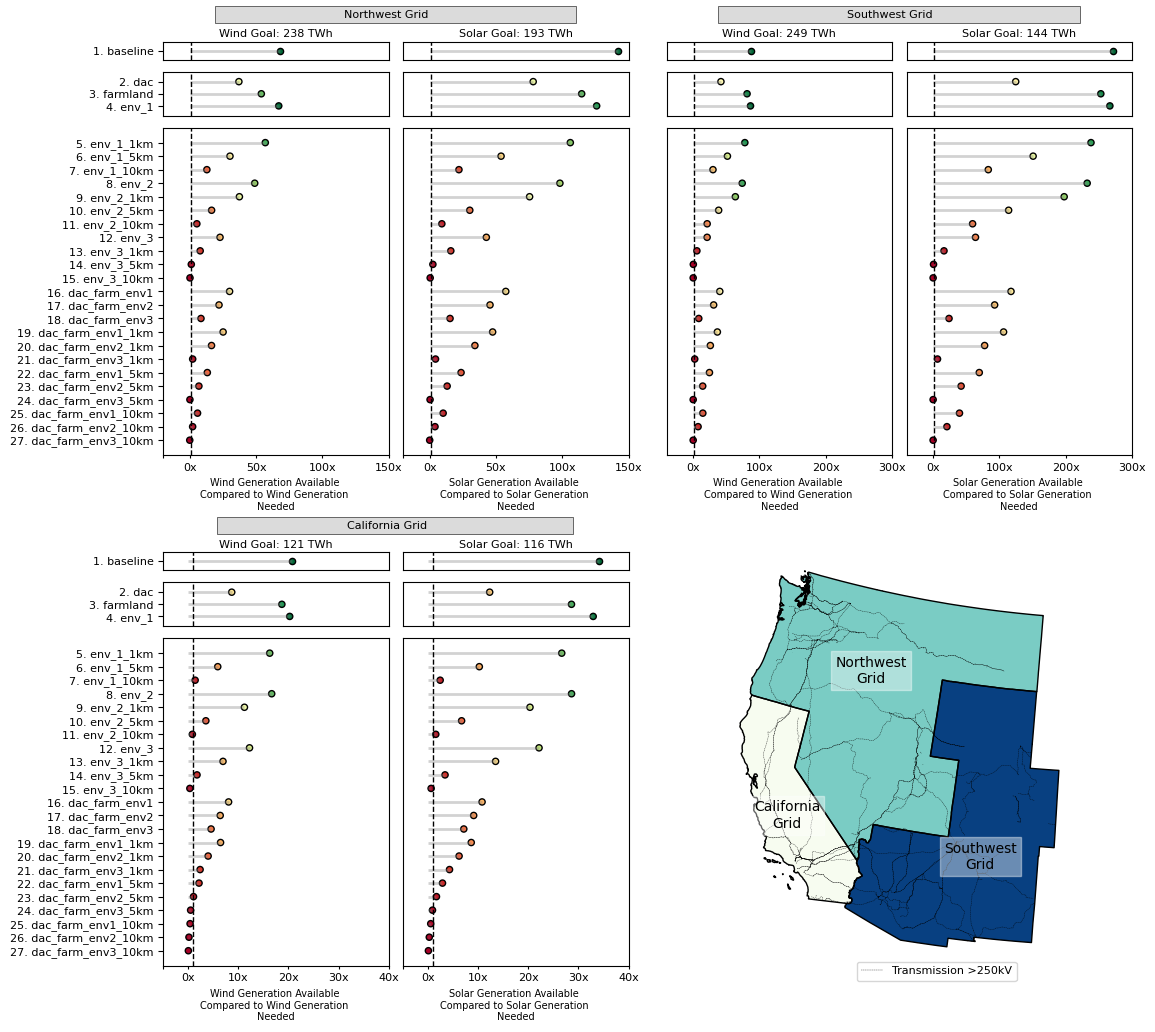

In [191]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=150)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=150)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=150)
ax.set_xticks(ticks=[-20,0,50, 100, 150], labels=['','0x','50x', '100x', '150x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=150)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=150)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=150)
ax.set_xticks(ticks=[-20,0,50, 100, 150], labels=['','0x','50x', '100x', '150x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=300)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=300)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=300)
ax.set_xticks(ticks=[ 0, 100, 200, 300], labels=['0x', '100x', '200x', '300x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=300)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=300)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=300)
ax.set_xticks(ticks=[0, 100, 200, 300], labels=['0x', '100x', '200x', '300x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=40)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=40)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.label.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=40)
ax.set_xticks(ticks=[-5, 0, 10, 20, 30, 40], labels=['','0x','10x', '20x', '30x', '40x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=40)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=40)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=40)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40], labels=['','0x', '10x','20x', '30x','40x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_12wind_30solar_100m.png'), dpi=300, bbox_inches='tight',)


plt.show()

## High Power Density Sensitivity case, 100m hub height

In [192]:
# state case
wind = base_df[base_df.technology == 'Wind_100m'].copy()
wind = wind[wind.capacity_density_mw == 18].copy()
wind['Rank'] = wind['case'].map(sorterIndex)
wind.sort_values(['Rank'], ascending = [False], inplace = True)
wind['target_generation_twh'] = wind['target_generation_mwh'] / 1000000
wind['total_generation_twh'] = wind['total_generation_mwh'] / 1000000
wind['diff'] = (wind['total_generation_twh'] / wind['target_generation_twh'])
region_list = sorted(list(wind.region_name.unique()))
case_list = (list(wind.case.unique()))

solar = base_df[base_df.technology == 'Solar PV'].copy()
solar['Rank'] = solar['case'].map(sorterIndex)
solar = solar[solar.capacity_density_mw == 45].copy()
solar.sort_values(['Rank'], ascending = [False], inplace = True)
solar['target_generation_twh'] = solar['target_generation_mwh'] / 1000000
solar['total_generation_twh'] = solar['total_generation_mwh'] / 1000000
solar['diff'] =  (solar['total_generation_twh'] / solar['target_generation_twh'])
region_list = sorted(list(solar.region_name.unique()))
case_list = (list(solar.case.unique()))

# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_100m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 18]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 45].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [193]:
high_wind_trading_100 = wind_trading.copy()
high_wind_trading_100['type'] = 'high'
high_wind_trading_100['cap'] = 18
high_wind_trading_100['tech'] = 'Wind_100m'
high_solar_trading_100 = solar_trading.copy()
high_solar_trading_100['type'] = 'high'
high_solar_trading_100['cap'] = 45
high_solar_trading_100['tech'] = 'solar_100'

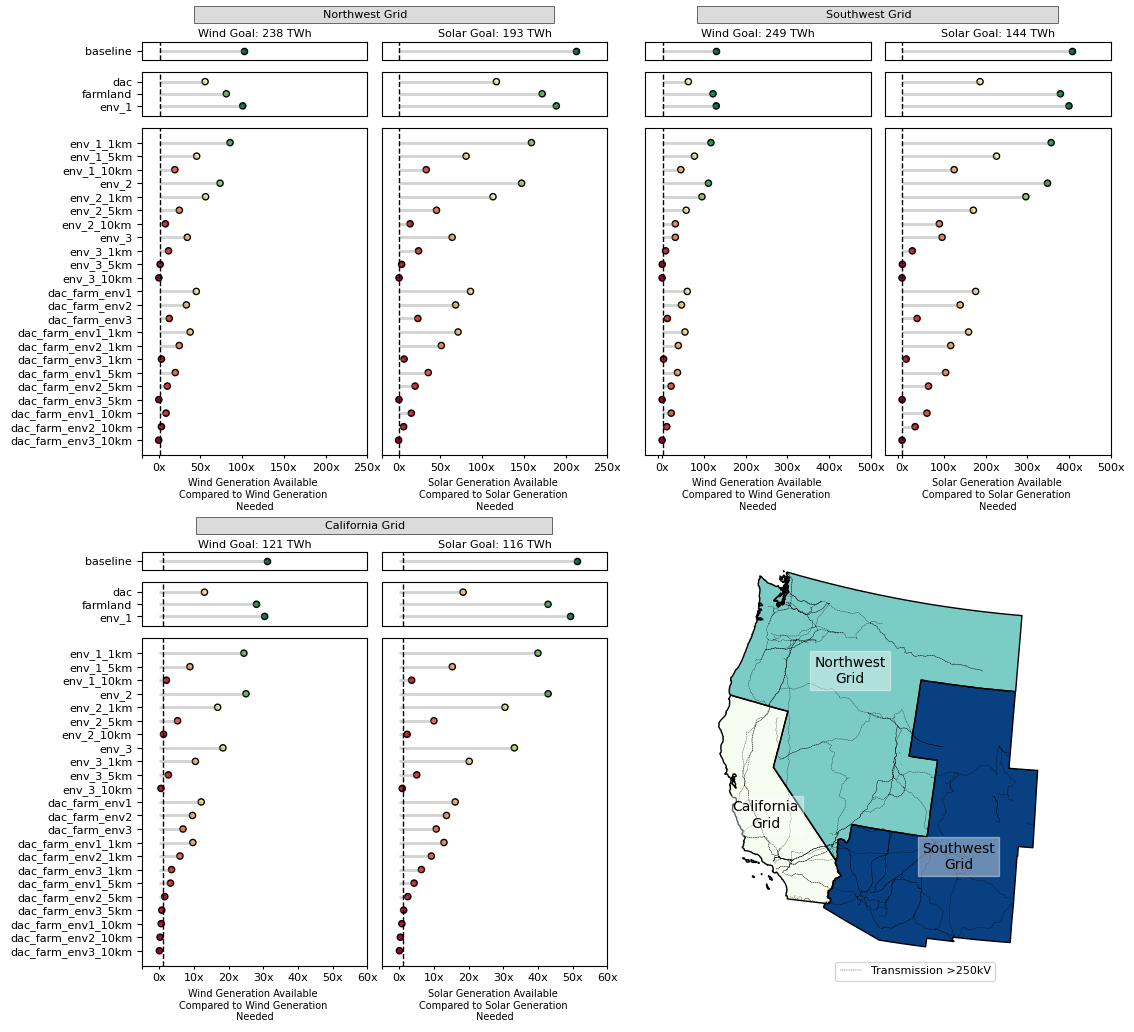

In [194]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_18wind_45solar_100m.png'), dpi=300, bbox_inches='tight',)

plt.show()

## Extra High Power Density Sensitivity case, 100m hub height

In [195]:
# state case
wind = base_df[base_df.technology == 'Wind_100m'].copy()
wind = wind[wind.capacity_density_mw == 24].copy()
wind['Rank'] = wind['case'].map(sorterIndex)
wind.sort_values(['Rank'], ascending = [False], inplace = True)
wind['target_generation_twh'] = wind['target_generation_mwh'] / 1000000
wind['total_generation_twh'] = wind['total_generation_mwh'] / 1000000
wind['diff'] = (wind['total_generation_twh'] / wind['target_generation_twh'])
region_list = sorted(list(wind.region_name.unique()))
case_list = (list(wind.case.unique()))

solar = base_df[base_df.technology == 'Solar PV'].copy()
solar['Rank'] = solar['case'].map(sorterIndex)
solar = solar[solar.capacity_density_mw == 60].copy()
solar.sort_values(['Rank'], ascending = [False], inplace = True)
solar['target_generation_twh'] = solar['target_generation_mwh'] / 1000000
solar['total_generation_twh'] = solar['total_generation_mwh'] / 1000000
solar['diff'] =  (solar['total_generation_twh'] / solar['target_generation_twh'])
region_list = sorted(list(solar.region_name.unique()))
case_list = (list(solar.case.unique()))

# gcam trading region case
wind_trading = base_df[base_df.technology == 'Wind_100m'].copy()
wind_trading = wind_trading[wind_trading.capacity_density_mw == 24]
wind_trading = wind_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
wind_trading['Rank'] = wind_trading['case'].map(sorterIndex)
wind_trading.sort_values(['Rank'], ascending = [False], inplace = True)
wind_trading['target_generation_twh'] = wind_trading['target_generation_mwh'] / 1000000
wind_trading['total_generation_twh'] = wind_trading['total_generation_mwh'] / 1000000
wind_trading['diff'] = (wind_trading['total_generation_twh'] / wind_trading['target_generation_twh'])
trading_region_list = sorted(list(wind_trading.gcam_trading_region.unique()))
wind_trading_case_list = (list(wind_trading.case.unique()))

solar_trading = base_df[base_df.technology == 'Solar PV'].copy()
solar_trading = solar_trading[solar_trading.capacity_density_mw == 60].copy()
solar_trading = solar_trading.groupby(['gcam_trading_region', 'case', 'case_number'], as_index=False).sum()
solar_trading['Rank'] = solar_trading['case'].map(sorterIndex)
solar_trading.sort_values(['Rank'], ascending = [False], inplace = True)
solar_trading['target_generation_twh'] = solar_trading['target_generation_mwh'] / 1000000
solar_trading['total_generation_twh'] = solar_trading['total_generation_mwh'] / 1000000
solar_trading['diff'] = (solar_trading['total_generation_twh'] / solar_trading['target_generation_twh'])
trading_region_list = sorted(list(solar_trading.gcam_trading_region.unique()))
solar_trading_case_list = (list(solar_trading.case.unique()))

In [196]:
extra_high_wind_trading_100 = wind_trading.copy()
extra_high_wind_trading_100['type'] = 'extra_high'
extra_high_wind_trading_100['cap'] = 24
extra_high_wind_trading_100['tech'] = 'Wind_100m'
extra_high_solar_trading_100 = solar_trading.copy()
extra_high_solar_trading_100['cap'] = 60
extra_high_solar_trading_100['type'] = 'extra_high'
extra_high_solar_trading_100['tech'] = 'solar_100'

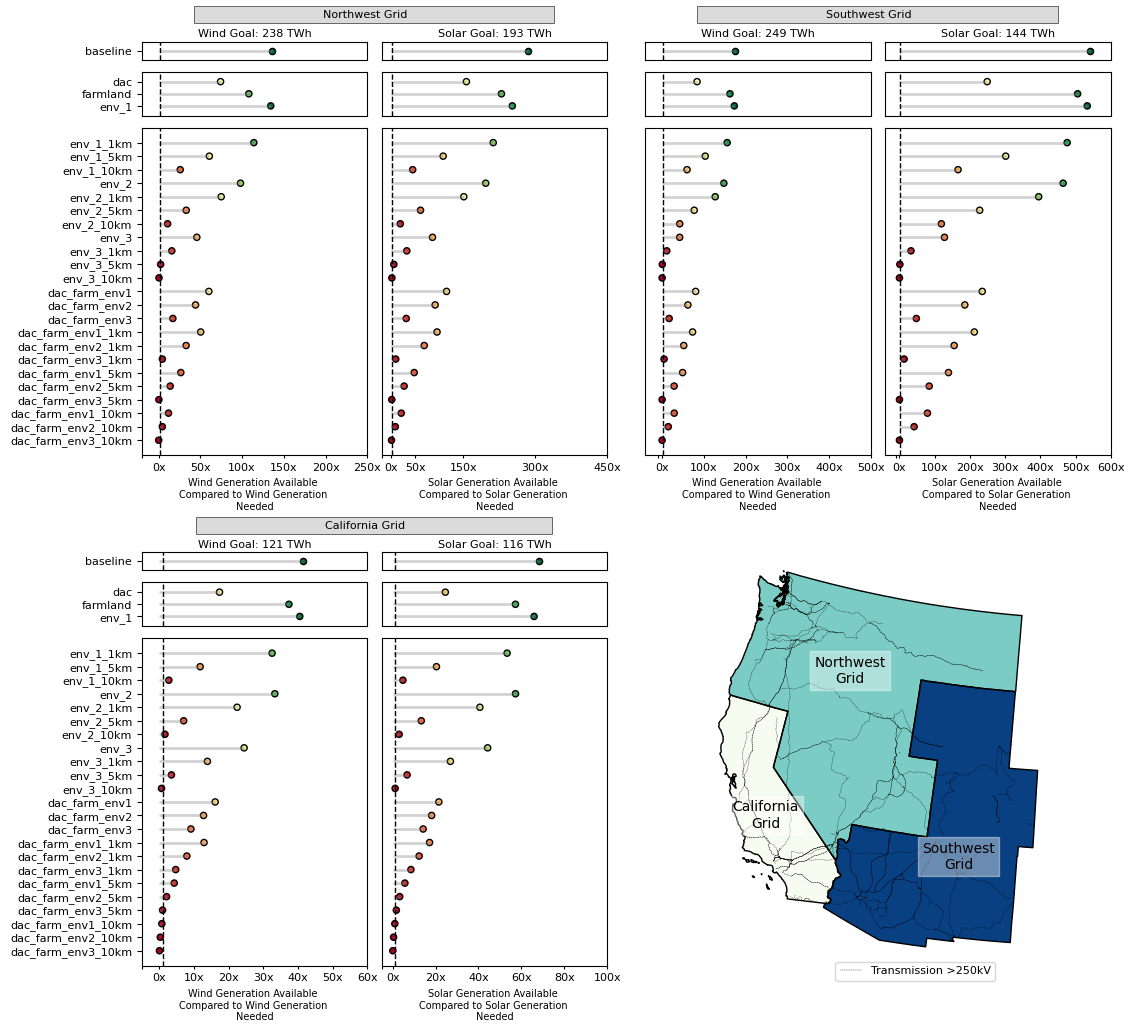

In [197]:
height = 12
width = 12.5

fig = plt.figure()
fig.set_figheight(height)
fig.set_figwidth(width)

spec = GridSpec(ncols=5, 
                nrows=7,
                width_ratios=[.25, .25, .01 , .25,.25], 
                wspace=0.08,
                hspace=0.1,
                height_ratios=[.05, .12, .9, .2, .05, .12, .9])


# top row set
ax_1a1 =fig.add_subplot(spec[0,0])
ax_1a2 =fig.add_subplot(spec[1,0])
ax_1a3 =fig.add_subplot(spec[2,0])

ax_1b1 =fig.add_subplot(spec[0,1])
ax_1b2 =fig.add_subplot(spec[1,1])
ax_1b3 =fig.add_subplot(spec[2,1])


# sw grid wind
ax_2a1 =fig.add_subplot(spec[0,3])
ax_2a2 =fig.add_subplot(spec[1,3])
ax_2a3 =fig.add_subplot(spec[2,3])

# sw grid solar
ax_2b1 =fig.add_subplot(spec[0,4])
ax_2b2 =fig.add_subplot(spec[1,4])
ax_2b3 =fig.add_subplot(spec[2,4])

# filler row
ax_filler = fig.add_subplot(spec[3,:])

# second row set
# ca wind
ax_3a1 =fig.add_subplot(spec[4,0])
ax_3a2 =fig.add_subplot(spec[5,0])
ax_3a3 =fig.add_subplot(spec[6,0])

# ca solar
ax_3b1 =fig.add_subplot(spec[4,1])
ax_3b2 =fig.add_subplot(spec[5,1])
ax_3b3 =fig.add_subplot(spec[6,1])

#map
ax_map =fig.add_subplot(spec[4:,3:])


### Settings ###
dot_cmap = 'RdYlGn'
dot_edgecolor = 'black'
dot_size=20
hline_alpha=.35
hlinew = 2
hlinecolor='grey'

###########################
##### Northwest Grid ######
###########################

x=1.03
y=2.75
ax_1a1.annotate(f"                                    Northwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Northwest WIND ###
# --------------------

region = 'NW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=250)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 100, 150, 200, 250], labels=['','0x','50x', '100x', '150x', '200x', '250x'])

#######

# --------------------
### Northwest SOLAR ###
# --------------------

region = 'NW Grid'
df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_1b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-20, right=450)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_1b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-20, right=450)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_1b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-20, right=250)
ax.set_xticks(ticks=[-20,0,50, 150, 300, 450], labels=['','0x','50x',  '150x','300x', '450x'])

#######

###########################
##### Southwest Grid ######
###########################

x=1.03
y=2.75
ax_2a1.annotate(f"                                    Southwest Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### Southwest WIND ###
# --------------------

region = 'SW Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_xlim(left=-40, right=500)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500], labels=['','0x', '100x', '200x', '300x', '400x', '500x'])

#######

# --------------------
### Southwest SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_2b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-40, right=600)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_2b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-40, right=600)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_2b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-40, right=500)
ax.set_xticks(ticks=[-10, 0, 100, 200, 300, 400, 500, 600], labels=['','0x', '100x', '200x', '300x', '400x', '500x', '600x'])


###########################
##### CA Grid ######
###########################

x=1.03
y=2.75
ax_3a1.annotate(f"                                    California Grid                                         ", 
               xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top', bbox=dict(boxstyle='square', fc='lightgray', 
                                                                 lw=.5, alpha=.8, color='black'))
# --------------------
### CA WIND ###
# --------------------

region = 'CA Grid'
df = wind_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3a1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df1.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.annotate(f"Wind Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3a2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df2.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=60)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3a3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.set_yticklabels(list(plot_df3.case.unique()))
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 10, 20, 30, 40, 50, 60], labels=['','0x', '10x','20x', '30x','40x', '50x', '60x'])

#######

# --------------------
### CA SOLAR ###
# --------------------

df = solar_trading
plot_df = df[df.gcam_trading_region == region]

x_val_max = plot_df['diff'].max() + 10
x_val_min = plot_df['diff'].min() - 10


vmax =max(plot_df.total_generation_twh.max(), plot_df.target_generation_twh.max())

# Baseline dots
plot_df1 = plot_df[plot_df.case == 'baseline']
my_range=range(1,len(plot_df1.index)+1)
ax=ax_3b1
ax.hlines(y=my_range, xmin=0, xmax=plot_df1['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df1['diff'], my_range, c=plot_df1['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
ax.set_xlim(left=-5, right=100)
ax.annotate(f"Solar Goal: {int(round(plot_df['target_generation_twh'].mean(), 0))} TWh", xy=(.5, 1.03), xytext=(.5, 1.7), xycoords='axes fraction', 
                    fontsize=8, ha='center', va='top')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)

# Existing dots
plot_df2 = plot_df[plot_df.case.isin(['dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df2.index)+1)
ax=ax_3b2
ax.hlines(y=my_range, xmin=0, xmax=plot_df2['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df2['diff'], my_range, c=plot_df2['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.set_xlim(left=-5, right=100)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, size=2, labelsize=8)
ax.margins(0.4)  

# Contribution dots
plot_df3 = plot_df[~plot_df.case.isin(['baseline', 'dac', 'farmland', 'env_1'])]
my_range=range(1,len(plot_df3.index)+1)
ax=ax_3b3
ax.hlines(y=my_range, xmin=0, xmax=plot_df3['diff'], color=hlinecolor, alpha=hline_alpha, lw=hlinew)
ax.scatter(plot_df3['diff'], my_range, c=plot_df3['total_generation_twh'], s = dot_size, edgecolor=dot_edgecolor, alpha=1 , cmap=dot_cmap, vmin=0, vmax=vmax)
ax.axvline(x = 1, linestyle='dashed', color = 'black', lw=1)
ax.set_yticks(my_range)
ax.tick_params(axis='y',which='both', bottom=False, top=False, left=False, labelleft=False, labelbottom=False)
plt.setp(ax.get_yticklabels(), size=8)
ax.tick_params(axis='x',which='both', bottom=True, top=False, labelbottom=True, size=2, labelsize=8)
ax.set_xlim(left=-5, right=60)
ax.set_xticks(ticks=[-5,0, 20, 40, 60, 80, 100], labels=['','0x', '20x', '40x',  '60x', '80x', '100x'])

#######


#### MAP #######

volt = Line2D([0], [0], color='black',linestyle='dashed', lw=.25, label='Transmission >250kV')
wecc_shp.plot(ax=ax_map,  column='trading_region', cmap='GnBu')
wecc_shp.boundary.plot(ax=ax_map, lw=1, color='black')
transmission.plot(ax=ax_map, color='black',linestyle='dashed', lw=.25)
ax_map.legend(handles=[volt], fontsize=8, title_fontsize = 8, loc='lower right', ncol=1, facecolor='white', bbox_to_anchor=(.85, -.05))


# region labels
ax_map.set_axis_off()
x=.42
y=.75
ax_map.annotate(f"Northwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.73
y=.3
ax_map.annotate(f"Southwest\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))
x=.18
y=.4 
ax_map.annotate(f"California\nGrid", xy=(x, y), xytext=(x, y), xycoords='axes fraction', 
                    fontsize=10, ha='center', va='top', bbox=dict(boxstyle='square', fc='white', alpha=.4, color='white'))


# X-axis Unit Labels
for ax in [ax_1a3,  ax_2a3, ax_3a3]:
    ax.set_xlabel('Wind Generation Available \nCompared to Wind Generation \nNeeded', size=7)
for ax in [ax_1b3,  ax_2b3, ax_3b3]:
    ax.set_xlabel('Solar Generation Available \nCompared to Solar Generation \nNeeded', size=7)

ax_map.set_axis_off()
ax_filler.set_axis_off()


plt.savefig(os.path.join(fig_dir, 'fig_si_24wind_60solar_100m.png'), dpi=300, bbox_inches='tight',)

plt.show()

### Summary Stats

In [199]:
d = pd.concat([base_wind_trading, base_solar_trading, base_wind_100_trading, base_solar_100_trading, 
               low_wind_trading_100, low_solar_trading_100, 
               high_wind_trading_100, high_solar_trading_100,
              extra_high_wind_trading_100, extra_high_solar_trading_100,
               low_wind_trading_120, low_solar_trading_120, 
               high_wind_trading_120, high_solar_trading_120,
              extra_high_wind_trading_120, extra_high_solar_trading_120
              ])
d = d[['gcam_trading_region', 'case', 'case_number', 
       'target_generation_twh', 'total_generation_twh', 'diff',	'type'	,'tech', 'cap']]

In [105]:
d_neg = d[d.target_generation_twh > d.total_generation_twh]
d_neg = d_neg[d_neg.tech != 'solar_100']
d_neg.groupby(['tech', 'cap']).count()

gcam_trading_region  case  case_number  target_generation_twh  \
tech      cap                                                                  
Solar     15                    14    14           14                     14   
          30                    12    12           12                     12   
          45                    11    11           11                     11   
          60                     8     8            8                      8   
Wind_100m 6                     17    17           17                     17   
          12                    13    13           13                     13   
          18                    12    12           12                     12   
          24                    12    12           12                     12   
Wind_120m 6                     17    17           17                     17   
          12                    13    13           13                     13   
          18                    12    12           12                     12   
          24                    12    12           12                     12   

               total_generation_twh  diff  type  
tech      cap                                    
Solar     15                     14    14     0  
          30                     12    12    12  
          45                     11    11    11  
          60                      8     8     8  
Wind_100m 6                      17    17    17  
          12                     13    13    13  
          18                     12    12    12  
          24                     12    12    12  
Wind_120m 6                      17    17    17  
          12                     13    13    13  
          18                     12    12    12  
          24                     12    12    12